<a href="https://colab.research.google.com/github/nimanik21/nimanikopour/blob/main/Financial_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What Exactly is PCA?

# Financial Applications

## Yield Curve Decomposition

Objective: we want to decompose hisotrical U.S. Treasury yields into their principal components to understand the key factors driving yield curve movements. The three main components are typically


1.   Levelp Parallel shifts in the yield curve
2.   Slope- Changes in the differnce between long and short term rates
3.   Curvature- changes in the middle curve realtive to the short and long end



In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import requests
import plotly.graph_objects as go

In [18]:
!pip install dash


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 11.7 MB/s eta 0:00:00
  Attempting uninstall: Werkzeug
    Found existing installation: Werkzeug 3.1.3
    Uninstalling Werkzeug-3.1.3:
      Successfully uninstalled Werkzeug-3.1.3
  Attempting uninstall: Flask
    Found existing installation: Flask 3.1.0
    Uninstalling Flask-3.1.0:
      Successfully uninstalled Flask-3.1.0


In [1]:
# Pull data from FRED

import json
import requests
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the file path to your API keys
file_path = "/content/drive/MyDrive/API/api_keys.json"

# Load API keys
with open(file_path, "r") as f:
    keys = json.load(f)

# Fetch FRED API key
fred_api_key = keys["FRED_API_KEY"]

# US Treasury yield series from FRED
yield_series = {
    "3M": "DGS3MO",
    "6M": "DGS6MO",
    "1Y": "DGS1",
    "2Y": "DGS2",
    "5Y": "DGS5",
    "10Y": "DGS10",
    "30Y": "DGS30"
}

def fetch_yield_data(series_id):
    """Fetch yield data from FRED for a given series ID."""
    endpoint = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": series_id,
        "api_key": fred_api_key,
        "file_type": "json"
    }
    response = requests.get(endpoint, params=params)
    data = response.json()

    return pd.DataFrame(
        [(obs["date"], float(obs["value"])) for obs in data["observations"] if obs["value"] != '.'],
        columns=["Date", series_id]
    )

print("FRED API Key Loaded Successfully")


Mounted at /content/drive
FRED API Key Loaded Successfully


In [2]:
# Fetch data for all maturities
yield_data = pd.DataFrame()
for label, series_id in yield_series.items():
    df = fetch_yield_data(series_id)
    if yield_data.empty:
        yield_data = df
    else:
        yield_data = yield_data.merge(df, on="Date", how="outer")

In [3]:
# Convert date column to datetime format
yield_data["Date"] = pd.to_datetime(yield_data["Date"])
yield_data.set_index("Date", inplace=True)
yield_data = yield_data.dropna()  # Drop missing values


Below is a plot of the U.S. Treasury Yield Curve at the most recent date. The yield curve shows the yield (rate of return) for different maturities of Treasury securities.

Typically, the yield curve slopes upward due to the 'term premium'—longer-term bonds offer higher yields to compensate for the increased risk of holding money for a longer period. However, at times, the curve can invert, meaning shorter-term bonds have higher yields than longer-term bonds.

An inverted yield curve is often viewed as a signal of an impending economic downturn. This happens because:
1. Investors seeking safety shift demand toward long-term bonds, pushing their yields lower.
2. Expectations of Federal Reserve rate cuts in response to economic weakness lead investors to buy short-term securities, anticipating their value will rise as rates decline.


In [11]:
import plotly.graph_objects as go

# Plot yield curve for the latest date using Plotly
latest_yields = yield_data.iloc[-1]
fig = go.Figure()
fig.add_trace(go.Scatter(x=list(yield_series.keys()), y=latest_yields,
                         mode='lines+markers',
                         name='Yield Curve',
                         line=dict(color='blue')))
fig.update_layout(title=f"US Treasury Yield Curve on {yield_data.index[-1].date()}",
                  xaxis_title="Maturity",
                  yaxis_title="Yield",
                  template="plotly_white")
fig.show()


Now will perform PCA on the yields: specifically on the yield changes instead of raw yield amounts. This will be used to understand how yields move together across maturities.

In [14]:
# Convert yields to percentage form
yield_data = yield_data.astype(float) / 100

# Compute yield changes
yield_changes = yield_data.diff().dropna()

# Apply PCA
pca = PCA()
pca.fit(yield_changes)


PCA()

In [16]:
import plotly.graph_objects as go
# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

# Principal components
eigenvectors = pca.components_
# Plot explained variance using Plotly
fig = go.Figure()
fig.add_trace(go.Bar(
    x=[f"PC{i+1}" for i in range(len(explained_variance))],
    y=explained_variance * 100,
    marker_color='blue'
))

fig.update_layout(
    title="Explained Variance by Principal Component",
    xaxis_title="Principal Component",
    yaxis_title="Variance Explained (%)",
    template="plotly_white"
)

fig.show()


In [20]:
import plotly.graph_objects as go
import numpy as np

# Compute cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_) * 100

# Create interactive plot
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=[f"PC{i+1}" for i in range(len(cumulative_variance))],
    y=cumulative_variance,
    mode='lines+markers',
    name='Cumulative Variance'
))

fig.update_layout(
    title="Cumulative Explained Variance of Yield Curve PCA",
    xaxis_title="Number of Principal Components",
    yaxis_title="Cumulative Variance Explained (%)",
    template="plotly_white"
)

fig.show()


By plotting the eigenvector coefficients, we can visualize how different maturities contribute to the principal components of the yield curve.

Eigenvectors represent the directions of maximum variance, and their coefficients (weights) indicate how much each maturity's yield change influences a given principal component.

In the yield curve PCA, each principal component is a linear combination of the original yield changes:

$$PC_i=a_1 \cdot(ΔY_{3M})+a_2 \cdot(ΔY_{6M})+...+a_n \cdot(ΔY_{30y})$$
where $a_1,a_2,...a_n$ are the eigenvector coeffcients (weights)

Thus, in the plot below, we can see the contribution of each maturity to the three major PC's.

In [23]:
import plotly.graph_objects as go

# Create an interactive plot of the first three principal components
fig = go.Figure()

# Add traces for PC1, PC2, and PC3
for i in range(3):
    fig.add_trace(go.Scatter(
        x=list(yield_series.keys()),
        y=eigenvectors[i],
        mode='lines+markers',
        name=f"PC{i+1}"
    ))

# Update layout
fig.update_layout(
    title="First Three Principal Components of the Yield Curve",
    xaxis_title="Maturity",
    yaxis_title="Eigenvector Coefficients",
    template="plotly_white",
    legend_title="Principal Components"
)

fig.show()


*   PC1 (Level Shift) has similar values across all maturities, indicating a
parallel movement of the entire yield curve—when interest rates rise or fall, they do so uniformly across all maturities.
*   PC2 (Slope Change) has high values for short-term maturities and low values for long-term maturities, meaning short-term and long-term rates move in opposite directions. This corresponds to steepening or flattening of the yield curve.


*   PC3 (Curvature Change) has high values at the short and long ends but low values in the middle, indicating a twist in the yield curve, where medium-term rates move differently from both short- and long-term rates.







In [ ]:
# Interpretation
print("First three principal components explained variance:")
print(f"Level: {explained_variance[0] * 100:.2f}%")
print(f"Slope: {explained_variance[1] * 100:.2f}%")
print(f"Curvature: {explained_variance[2] * 100:.2f}%")


First three principal components explained variance:
Level: 74.20%
Slope: 16.35%
Curvature: 4.50%


## EigenPortfolio


Eigenportfolios are portfolios of bonds constructed from the principal components (PCs) of yield curve movements. Each eigenportfolio represents a specific type of yield curve shift—parallel shifts, steepening/flattening, or curvature changes.

These portfolios are built using the eigenvectors from PCA, where the weights indicate how much each maturity contributes to the portfolio. Positive weights represent long positions, while negative weights imply shorting those bonds.

In practice, eigenportfolios allow traders to isolate and trade specific yield curve dynamics. If you expect a broad interest rate increase, you might short Eigenportfolio 1, which captures level shifts. If you anticipate steepening, you could go long Eigenportfolio 2, which is sensitive to short- vs. long-term rate divergences.

Eigenportfolios are used for risk management, portfolio construction, and yield curve trading, enabling a more systematic approach to interest rate movements.




In [32]:
portfolio_weights

{'BIL': 0.13939303392960853,
 'SGOV': 0.1577438903321045,
 'SHY': 0.1658579963068916,
 'VGSH': 0.1744951304805824,
 'IEI': 0.17665635123119447,
 'IEF': 0.16079238747290017,
 'TLT': 0.13525954433861848}

In [24]:
# Construct Eigenportfolios
# Each eigenportfolio corresponds to one of the principal components.
# The weights of each eigenportfolio are given by the eigenvectors of the covariance matrix.
eigenportfolios = eigenvectors[:3]  # First three eigenportfolios

# Normalize the eigenportfolios so that the sum of weights is 1
eigenportfolios = eigenportfolios / np.sum(np.abs(eigenportfolios), axis=1, keepdims=True)

# Display the eigenportfolio weights
print("Eigenportfolio weights:")
for i, eigenportfolio in enumerate(eigenportfolios):
    print(f"Eigenportfolio {i+1} (PC{i+1} exposure):")
    for maturity, weight in zip(yield_series.keys(), eigenportfolio):
        print(f"{maturity}: {weight:.4f}")
    print("\n")

Eigenportfolio weights:
Eigenportfolio 1 (PC1 exposure):
3M: 0.1256
6M: 0.1421
1Y: 0.1494
2Y: 0.1572
5Y: 0.1591
10Y: 0.1448
30Y: 0.1218


Eigenportfolio 2 (PC2 exposure):
3M: 0.2649
6M: 0.1721
1Y: 0.0765
2Y: -0.0357
5Y: -0.1304
10Y: -0.1632
30Y: -0.1572


Eigenportfolio 3 (PC3 exposure):
3M: 0.2371
6M: -0.0701
1Y: -0.1656
2Y: -0.1912
5Y: -0.0298
10Y: 0.1045
30Y: 0.2018




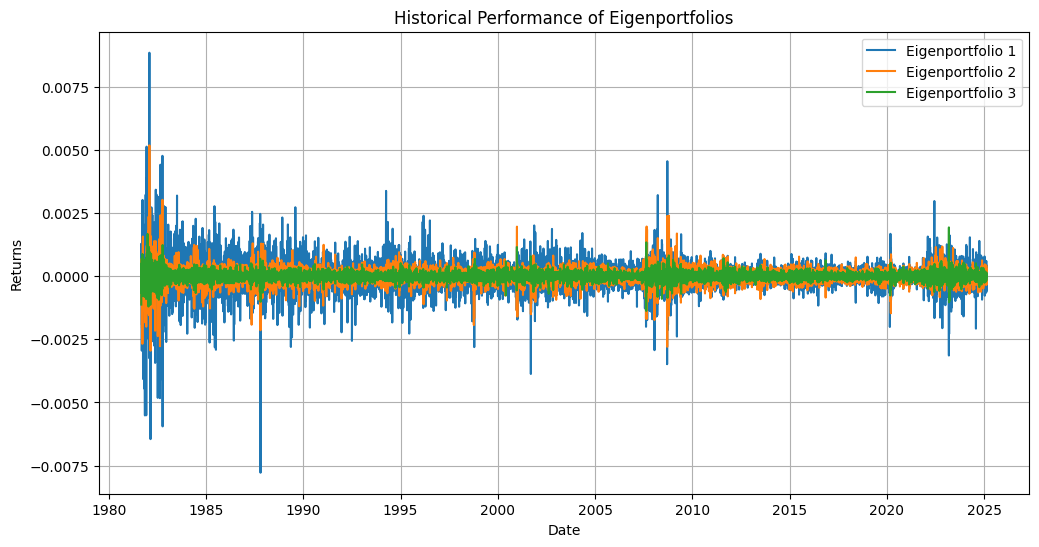

In [ ]:
# Visualize historical movements of the eigenportfolios
eigenportfolio_returns = yield_changes @ eigenportfolios.T  # Project yield changes onto eigenportfolios

plt.figure(figsize=(12, 6))
for i in range(3):
    plt.plot(eigenportfolio_returns.index, eigenportfolio_returns.iloc[:, i], label=f"Eigenportfolio {i+1}")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.title("Historical Performance of Eigenportfolios")
plt.legend()
plt.grid()
plt.show()

## Risk Factor Extraction with PCA

In [ ]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("everget/government-bonds")

# List files in the dataset directory
files = os.listdir(path)
print("Files in directory:", files)




Files in directory: ['prices.csv', 'yields.csv']


In [ ]:
price_dataset_path = f"{path}/prices.csv"
df = pd.read_csv(price_dataset_path)

yields_price_dataset_path = f"{path}/yields.csv"
yields_df = pd.read_csv(yields_price_dataset_path)

In [ ]:
# Convert time column to datetime format
yields_df["time"] = pd.to_datetime(yields_df["time"], unit="ms")

# Check for missing values and zero values
missing_values = yields_df.isnull().sum().sum()
zero_values = (yields_df == 0).sum().sum()

# Summary statistics
summary_stats = yields_df.describe()

missing_values, zero_values, summary_stats


(1759758,
 0,
                                 time         AU01          AU02         AU03  \
 count                          12787  5173.000000  10265.000000  5173.000000   
 mean   1995-03-26 01:10:07.695315456     3.789838      7.148046     3.922441   
 min              1970-01-05 14:30:00     0.107700      0.187300     0.201300   
 25%              1982-08-25 01:30:00     2.005000      4.330000     2.143000   
 50%              1995-03-06 14:30:00     4.140000      5.680000     4.520000   
 75%              2007-11-11 02:30:00     5.250000     11.480000     5.320000   
 max              2020-07-24 13:30:00     7.260000     16.600000     7.060000   
 std                              NaN     1.755790      4.370052     1.769829   
 
                AU05         AU07          AU10         AU15        AU20  \
 count  10265.000000  1081.000000  10265.000000  5173.000000  187.000000   
 mean       7.428845     1.906446      7.671842     4.691932    1.502934   
 min        0.286800     0.

In [ ]:
# Calculate the proportion of zero values for each column
zero_proportions = (df_new == 0).sum() / len(df_new)

# Sort columns by the highest proportion of zero values
zero_proportions_sorted = zero_proportions.sort_values(ascending=False)

# Display columns with significant zero values (above 50%)
zero_proportions_sorted[zero_proportions_sorted > 0.5]
